In [29]:
# ----- Setup -----
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [30]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [31]:
# ----- Load Zara 2 Data -----
df = pd.read_csv("converted_zara_2.csv")
x_mean, x_std = df['x'].mean(), df['x'].std()
y_mean, y_std = df['y'].mean(), df['y'].std()
df['x'] = (df['x'] - x_mean) / x_std
df['y'] = (df['y'] - y_mean) / y_std

SEQ_LEN = 8
PRED_LEN = 15


In [32]:
# ----- Dataset Definition -----
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        obs, fut = self.trajectories[idx]
        return torch.tensor(obs, dtype=torch.float32), torch.tensor(fut, dtype=torch.float32)


In [33]:
# ----- Rebuild Zara 2 Trajectories -----
trajectories = []
for pid, person_df in df.groupby("person_id"):
    person_df = person_df.sort_values("frame_id")
    coords = person_df[['x', 'y']].values
    for i in range(len(coords) - SEQ_LEN - PRED_LEN):
        obs = coords[i:i+SEQ_LEN]
        fut = coords[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN]
        trajectories.append((obs, fut))

data_loader = DataLoader(TrajectoryDataset(trajectories), batch_size=64, shuffle=False)

# ----- Load Metadata from Training -----
with open("/content/Models/results_metadata.json", "r") as f:  #----!
    metadata = pd.read_json(f)  #----!


In [34]:
# ----- LSTM Model Definition (same as before) -----
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_len, num_layers, dropout, bidirectional):
        super(LSTMModel, self).__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional
        )
        direction_multiplier = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction_multiplier, 2 * output_len)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        hn = torch.cat((hn[-2], hn[-1]), dim=1) if self.bidirectional else hn[-1]
        out = self.fc(hn)
        return out.view(-1, self.fc.out_features // 2, 2)

In [36]:
# ----- Evaluate Saved Models on Zara 2 -----
results = []
criterion = nn.MSELoss()

for _, row in metadata.iterrows():
    exp_id = row["experiment_id"]
    model_path = f"/content/Models/lstm_zara_exp_{exp_id}.pth"
    if not os.path.exists(model_path):
        continue

    model = LSTMModel(
        input_size=2,
        hidden_size=row["hidden_size"],
        output_len=row["pred_len"],
        num_layers=row["num_layers"],
        dropout=row["dropout"],
        bidirectional=row["bidirectional"]
    ).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval().to(device)
    total_loss = 0
    with torch.no_grad():
        for obs, fut in data_loader:
            pred = model(obs.to(device))
            loss = criterion(pred.to(device), fut.to(device))
            total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    results.append({**row.to_dict(), "zara2_loss": avg_loss})  #----!

<ipython-input-37-59ac5ee9dd5c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="experiment_id", y="zara2_loss", palette="viridis")


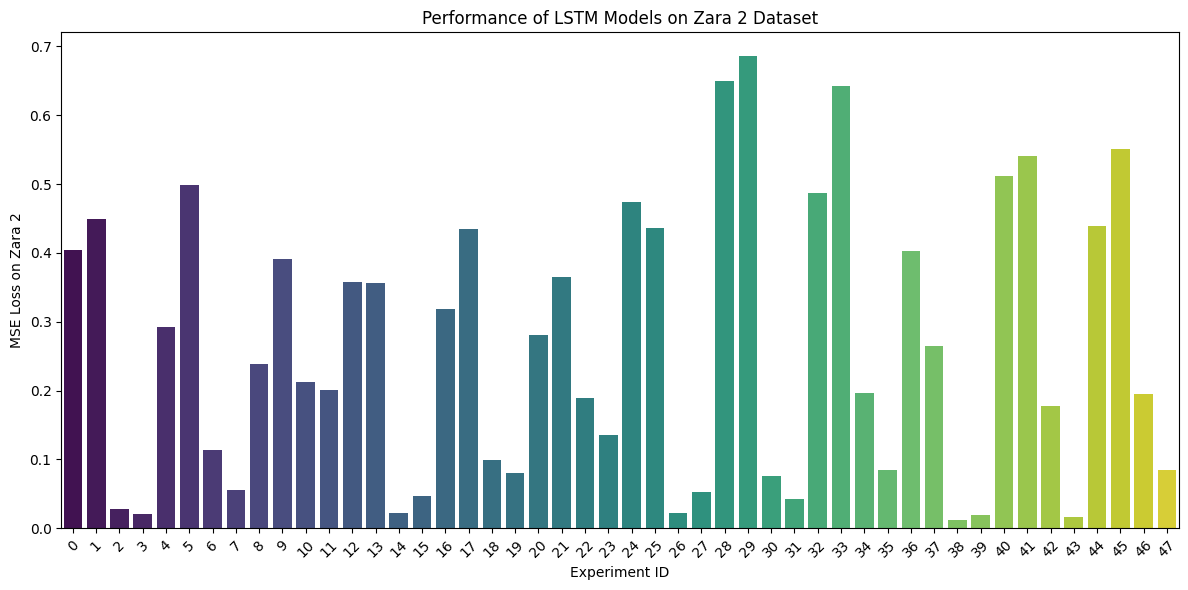

In [37]:
# ----- Visualize Combined Results -----
results_df = pd.DataFrame(results).sort_values("zara2_loss")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="experiment_id", y="zara2_loss", palette="viridis")
plt.title("Performance of LSTM Models on Zara 2 Dataset")
plt.xlabel("Experiment ID")
plt.ylabel("MSE Loss on Zara 2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

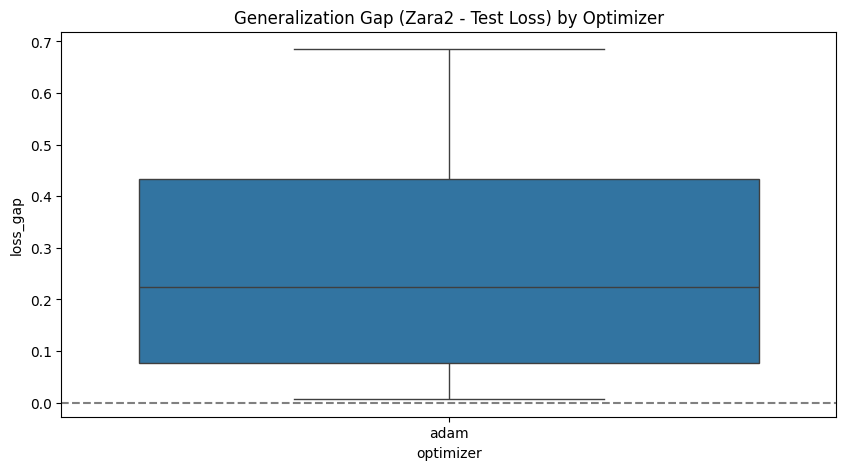

<ipython-input-38-cc61bbe9d044>:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_df, x="dropout", y="loss_gap", ci="sd")


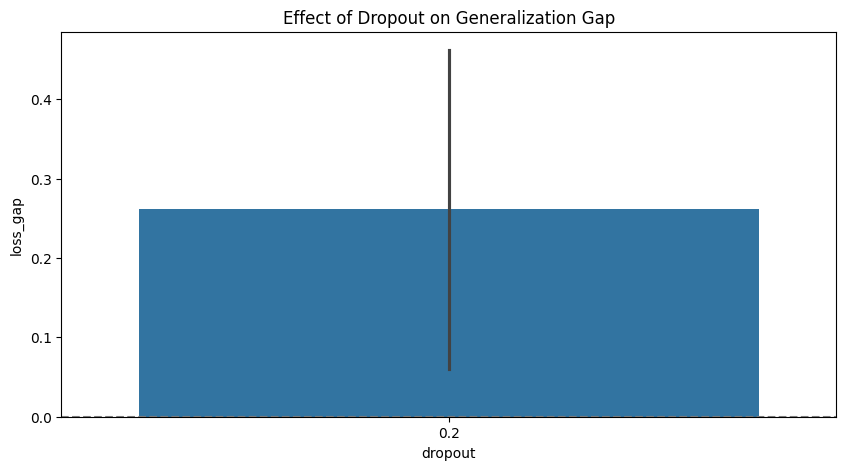

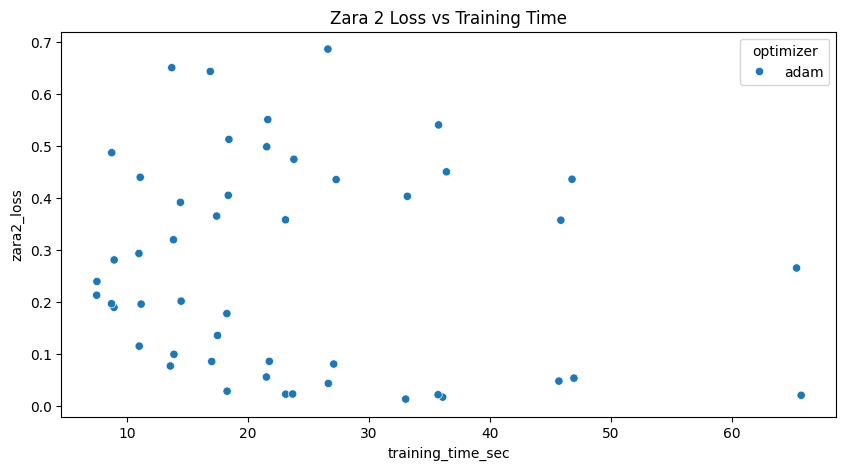

In [38]:
# ---- Extra Analysis: Generalization Gap ----
results_df["loss_gap"] = results_df["zara2_loss"] - results_df["test_loss"]  #----!

plt.figure(figsize=(10, 5))
sns.boxplot(data=results_df, x="optimizer", y="loss_gap")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Generalization Gap (Zara2 - Test Loss) by Optimizer")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="dropout", y="loss_gap", ci="sd")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Effect of Dropout on Generalization Gap")
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=results_df, x="training_time_sec", y="zara2_loss", hue="optimizer")
plt.title("Zara 2 Loss vs Training Time")
plt.show()

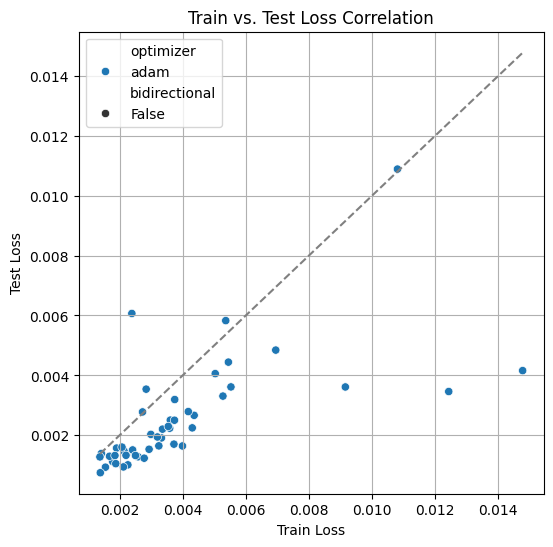

In [39]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=results_df, x="train_loss", y="test_loss", hue="optimizer", style="bidirectional")
plt.plot([results_df.train_loss.min(), results_df.train_loss.max()],
         [results_df.train_loss.min(), results_df.train_loss.max()], linestyle='--', color='gray')
plt.title("Train vs. Test Loss Correlation")
plt.xlabel("Train Loss")
plt.ylabel("Test Loss")
plt.grid(True)
plt.show()
